In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


## Loading Dataset : ( Hotel Booking Dataset )

In [11]:
Original_Data = pd.read_csv("hotel_booking_dataset.csv")

df = Original_Data.copy()

df.head()

,hotel_type,lead_time,arrival_month,weekend_nights,week_nights,adults,children,meal_plan,country,parking_requests,room_price,is_canceled
0,Resort Hotel,67,Jan,1,4,4,0.0,SC,UK,2,161.26,1
1,City Hotel,138,May,3,8,2,1.0,BB,India,1,87.82,1
2,City Hotel,225,Feb,0,9,4,2.0,SC,USA,0,135.72,1
3,Resort Hotel,61,Aug,2,2,3,0.0,SC,France,1,209.19,1
4,City Hotel,102,Jul,3,9,3,1.0,HB,Germany,1,42.11,1


## Basic Info :

In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hotel_type        5500 non-null   object 
 1   lead_time         5500 non-null   int64  
 2   arrival_month     5500 non-null   object 
 3   weekend_nights    5500 non-null   int64  
 4   week_nights       5500 non-null   int64  
 5   adults            5500 non-null   int64  
 6   children          5170 non-null   float64
 7   meal_plan         5500 non-null   object 
 8   country           5170 non-null   object 
 9   parking_requests  5500 non-null   int64  
 10  room_price        5170 non-null   float64
 11  is_canceled       5500 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 515.8+ KB


,lead_time,weekend_nights,week_nights,adults,children,parking_requests,room_price,is_canceled
count,5500.000000,5500.000000,5500.000000,5500.000000,5170.000000,5500.000000,5170.000000,5500.000000
mean,182.824000,1.978364,5.007455,2.512000,1.492456,0.985091,120.191230,0.507273
std,105.130374,1.428315,2.601869,1.113834,1.121054,0.818141,40.925482,0.499993
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,-28.820000,0.000000
25%,90.750000,1.000000,3.000000,2.000000,0.000000,0.000000,92.802500,0.000000
50%,185.000000,2.000000,5.000000,2.000000,1.000000,1.000000,120.825000,1.000000
75%,273.000000,3.000000,7.000000,4.000000,2.000000,2.000000,147.835000,1.000000
max,364.000000,4.000000,9.000000,4.000000,3.000000,2.000000,258.420000,1.000000


## EDA : ( Exploratory Data Analysis )

### Univariate Analysis 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2992\1419967334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel_type', data=df, palette='Set2', ax=axes[1,0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2992\1419967334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='arrival_month', data=df, palette='pastel', ax=axes[1,1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2992\1419967334.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='coolwarm', ax=axes[1,2])


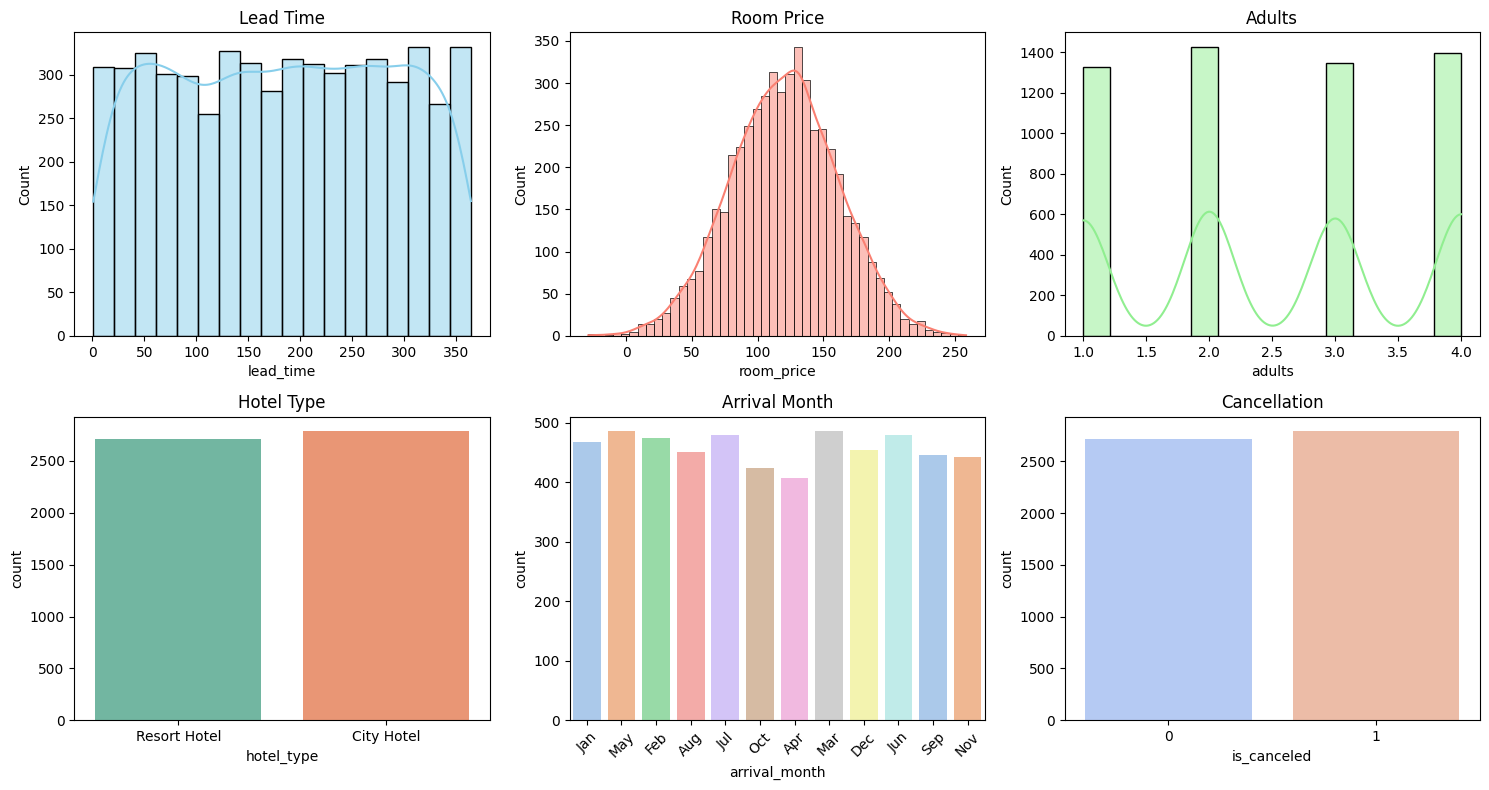

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df['lead_time'], kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title("Lead Time")

sns.histplot(df['room_price'], kde=True, color='salmon', ax=axes[0,1])
axes[0,1].set_title("Room Price")

sns.histplot(df['adults'], kde=True, color='lightgreen', ax=axes[0,2])
axes[0,2].set_title("Adults")

sns.countplot(x='hotel_type', data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title("Hotel Type")

sns.countplot(x='arrival_month', data=df, palette='pastel', ax=axes[1,1])
axes[1,1].set_title("Arrival Month")
axes[1,1].tick_params(axis='x', rotation=45)

sns.countplot(x='is_canceled', data=df, palette='coolwarm', ax=axes[1,2])
axes[1,2].set_title("Cancellation")

plt.tight_layout()
plt.show()


### Bivariate Analysis

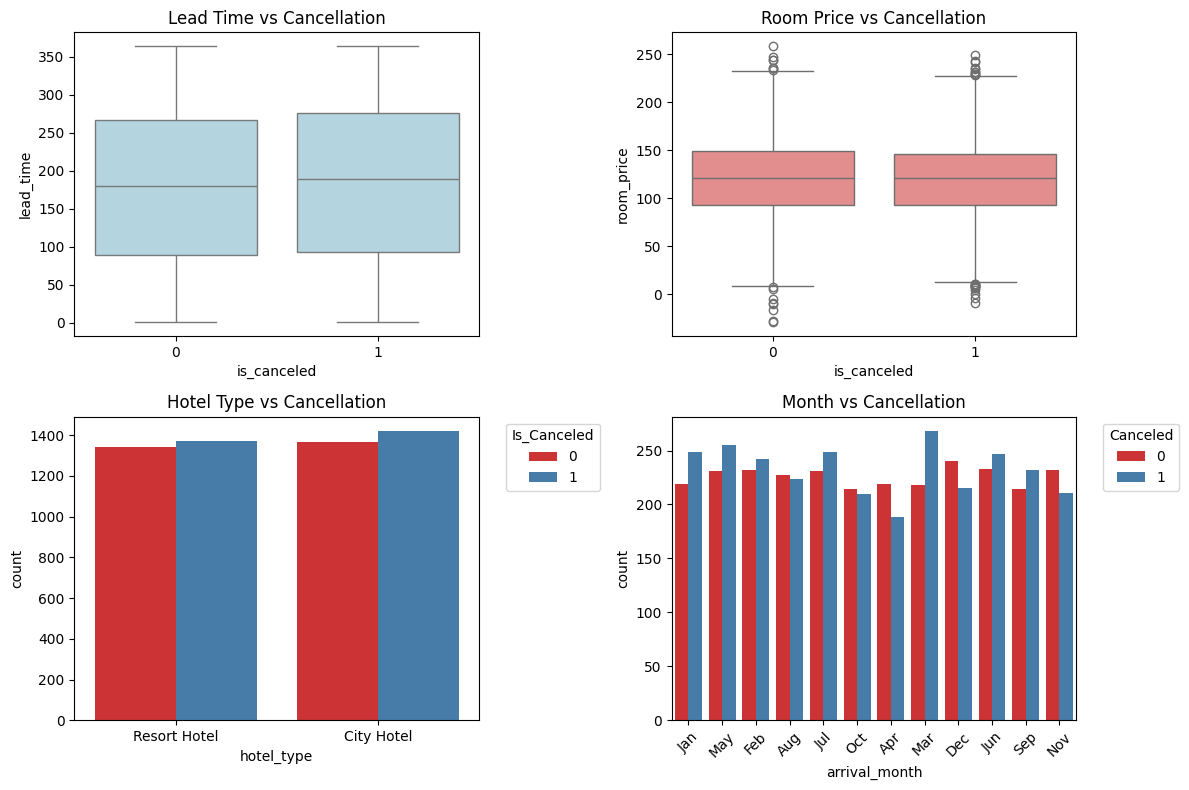

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x='is_canceled', y='lead_time', data=df, color='lightblue', ax=axes[0,0])
axes[0,0].set_title("Lead Time vs Cancellation")

sns.boxplot(x='is_canceled', y='room_price', data=df, color='lightcoral', ax=axes[0,1])
axes[0,1].set_title("Room Price vs Cancellation")

sns.countplot(x='hotel_type', hue='is_canceled', data=df, palette='Set1', ax=axes[1,0])
axes[1,0].set_title("Hotel Type vs Cancellation")
axes[1,0].legend(title="Is_Canceled", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.countplot(x='arrival_month', hue='is_canceled', data=df, palette='Set1', ax=axes[1,1])
axes[1,1].set_title("Month vs Cancellation")
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(title="Canceled", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()


### Multivariate Analysis 

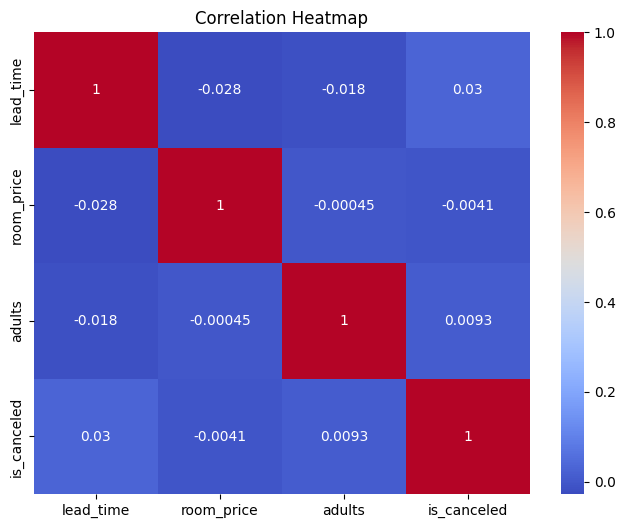

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['lead_time','room_price','adults','is_canceled']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


## Missing Value Identification and Percentage :

In [16]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percent,
})

missing_df

,Missing Count,Missing (%)
hotel_type,0,0.0
lead_time,0,0.0
arrival_month,0,0.0
weekend_nights,0,0.0
week_nights,0,0.0
adults,0,0.0
children,330,6.0
meal_plan,0,0.0
country,330,6.0
parking_requests,0,0.0


In [17]:
df.dtypes

hotel_type           object
lead_time             int64
arrival_month        object
weekend_nights        int64
week_nights           int64
adults                int64
children            float64
meal_plan            object
country              object
parking_requests      int64
room_price          float64
is_canceled           int64
dtype: object

## Checking Distribution : (Missing Numerical Feature Only)

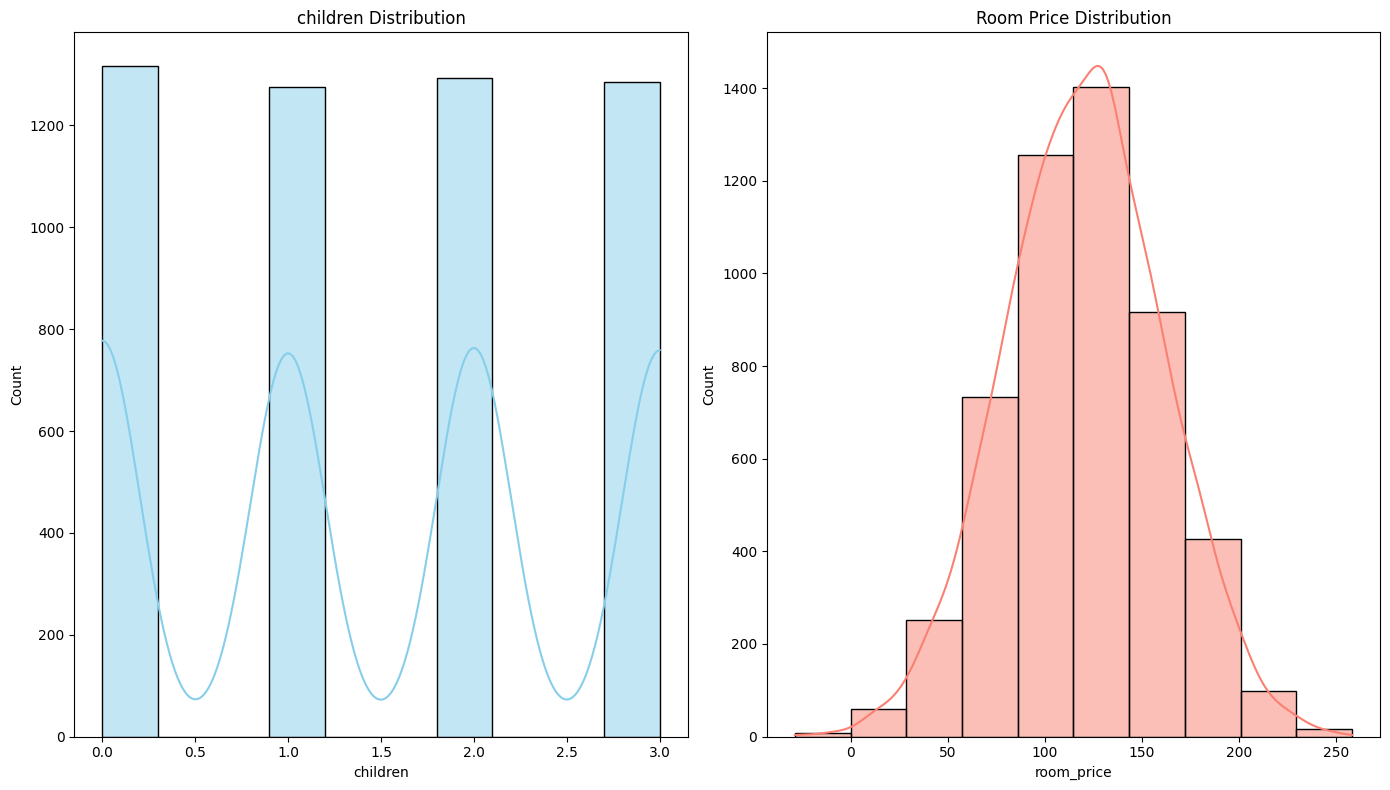

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['children'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('children Distribution')

sns.histplot(df['room_price'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Room Price Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [19]:
mean_imputer = SimpleImputer(strategy='mean')

df['room_price'] = mean_imputer.fit_transform(df[['room_price']])

In [20]:
median_imputer = SimpleImputer(strategy= 'median')

df['children'] = median_imputer.fit_transform(df[['children']])

In [21]:
df['country'].value_counts()

country
France     884
UK         871
UAE        863
Germany    853
USA        852
India      847
Name: count, dtype: int64

In [22]:
df['country_missing'] = (df['country'].isnull().astype(int))

In [23]:
mode_imputer = SimpleImputer(strategy='most_frequent')

df['country'] = (mode_imputer.fit_transform(df[['country']]).ravel())

In [24]:
df.isnull().sum()

hotel_type          0
lead_time           0
arrival_month       0
weekend_nights      0
week_nights         0
adults              0
children            0
meal_plan           0
country             0
parking_requests    0
room_price          0
is_canceled         0
country_missing     0
dtype: int64

In [25]:
df.head()

,hotel_type,lead_time,arrival_month,weekend_nights,week_nights,adults,children,meal_plan,country,parking_requests,room_price,is_canceled,country_missing
0,Resort Hotel,67,Jan,1,4,4,0.0,SC,UK,2,161.26,1,0
1,City Hotel,138,May,3,8,2,1.0,BB,India,1,87.82,1,0
2,City Hotel,225,Feb,0,9,4,2.0,SC,USA,0,135.72,1,0
3,Resort Hotel,61,Aug,2,2,3,0.0,SC,France,1,209.19,1,0
4,City Hotel,102,Jul,3,9,3,1.0,HB,Germany,1,42.11,1,0


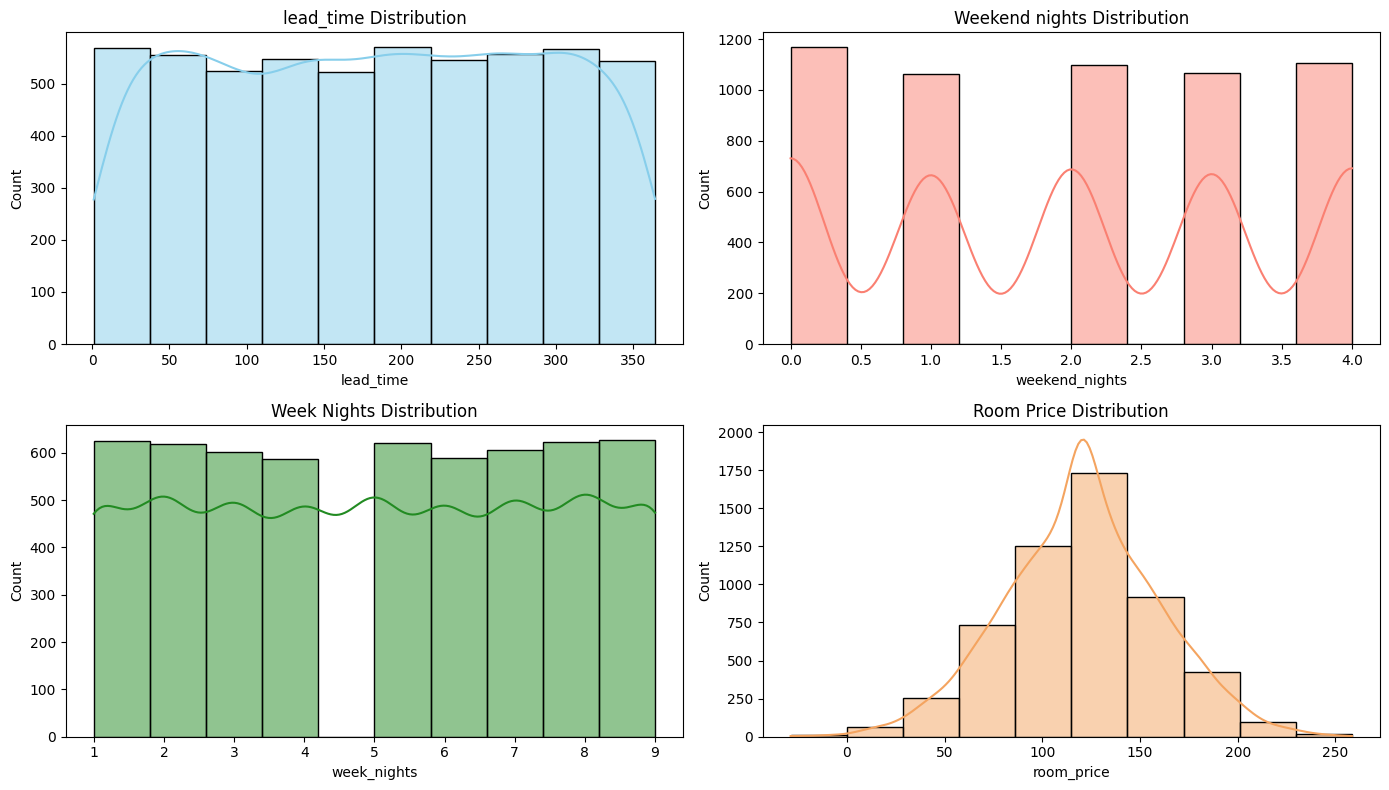

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['lead_time'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('lead_time Distribution')

sns.histplot(df['weekend_nights'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Weekend nights Distribution')

sns.histplot(df['week_nights'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Week Nights Distribution')

sns.histplot(df['room_price'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Room Price Distribution')

plt.tight_layout()
plt.show()

## Feature Construction and Encoding :

In [27]:
month_order = [[
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]]

oe = OrdinalEncoder(categories=month_order)

df['arrival_month'] = oe.fit_transform(df[['arrival_month']])


In [28]:
onehot_cols = ['hotel_type', 'meal_plan', 'country']

onehot_encoder = OneHotEncoder(drop='first',  sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df.index
)

df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)

In [29]:
df['total_nights'] = (
    df['weekend_nights'] +
    df['week_nights']
)

df['total_guests'] = (
    df['adults'] +
    df['children']
)

df['price_per_night'] = (
    df['room_price'] /
    (df['total_nights'] + 1)
)

df['long_stay'] = (
    df['total_nights'] > 5
).astype(int)

In [30]:
df

,lead_time,arrival_month,weekend_nights,week_nights,adults,children,parking_requests,room_price,is_canceled,country_missing,...,meal_plan_SC,country_Germany,country_India,country_UAE,country_UK,country_USA,total_nights,total_guests,price_per_night,long_stay
0,67,0.0,1,4,4,0.0,2,161.26,1,0,...,1.0,0.0,0.0,0.0,1.0,0.0,5,4.0,26.876667,0
1,138,4.0,3,8,2,1.0,1,87.82,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,11,3.0,7.318333,1
2,225,1.0,0,9,4,2.0,0,135.72,1,0,...,1.0,0.0,0.0,0.0,0.0,1.0,9,6.0,13.572000,1
3,61,7.0,2,2,3,0.0,1,209.19,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,4,3.0,41.838000,0
4,102,6.0,3,9,3,1.0,1,42.11,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,12,4.0,3.239231,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,264,1.0,1,6,3,2.0,1,44.23,1,0,...,1.0,1.0,0.0,0.0,0.0,0.0,7,5.0,5.528750,1
5496,361,5.0,3,4,4,0.0,0,132.10,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,7,4.0,16.512500,1
5497,214,7.0,3,3,4,3.0,1,87.78,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,6,7.0,12.540000,1
5498,54,6.0,4,6,3,3.0,2,82.07,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,10,6.0,7.460909,1


## Feature Scaling :

In [31]:
num_cols = ['lead_time', 'weekend_nights','week_nights','adults','children',
'parking_requests','total_nights','total_guests','price_per_night','long_stay',
'room_price','arrival_month'
]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [32]:
Clean_dataset = df.copy()

Clean_dataset.head()

,lead_time,arrival_month,weekend_nights,week_nights,adults,children,parking_requests,room_price,is_canceled,country_missing,...,meal_plan_SC,country_Germany,country_India,country_UAE,country_UK,country_USA,total_nights,total_guests,price_per_night,long_stay
0,-1.101818,-1.576107,-0.685040,-0.387239,1.336047,-1.338347,1.240620,1.035133,1,0,...,1.0,0.0,0.0,0.0,1.0,0.0,-0.667759,0.016083,0.710311,-1.379821
1,-0.426405,-0.415148,0.715339,1.150257,-0.459715,-0.423494,0.018225,-0.815912,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.349825,-0.624901,-0.901604,0.724731
2,0.401215,-1.285868,-1.385229,1.534631,1.336047,0.491359,-1.204170,0.391400,1,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.677297,1.298051,-0.386203,0.724731
3,-1.158895,0.455571,0.015150,-1.155988,0.438166,-1.338347,0.018225,2.243201,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,-1.004024,-0.624901,1.943361,-1.379821
4,-0.768868,0.165331,0.715339,1.534631,0.438166,-0.423494,0.018225,-1.968026,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.686090,0.016083,-1.237786,0.724731
